# Laboratorio 1 Trabajo grupal de interpretación

**Módulo III · Sesión 5 · Integración de preparación y calidad de datos**  
**Modalidad:** seis grupos de trabajo · **Ponderación:** 10% del módulo · **Tiempo:** 75 minutos

## Propósito

El grupo construirá una Capa Silver a partir de un archivo Bronze industrial. El código Python ya está preparado y no constituye el objetivo principal. La evidencia calificada será la capacidad del grupo para **leer resultados, identificar problemas de calidad, justificar reglas y comunicar decisiones industriales**.

> **Regla de trabajo:** ningún integrante se limita a “hacer el código”. Todos deben revisar las tablas y gráficos, discutir la evidencia y aportar a la interpretación final. El docente puede solicitar a cualquier integrante que explique una decisión del grupo.


## Acuerdo de trabajo del grupo

Antes de ejecutar, registren el número de grupo y los integrantes. Pueden distribuir roles de apoyo —coordinación, lectura de calidad, revisión de reglas, interpretación de gráficos, control de validaciones y relatoría—, pero los roles no dividen el aprendizaje: **todos deben comprender el flujo completo**.

La única entrega es este notebook ejecutado, con las salidas visibles y las respuestas de interpretación en las celdas Markdown indicadas. El código puede generar archivos CSV auxiliares para documentar el flujo, pero no se entregan por separado.


In [ ]:
# 0. Identificación del grupo
# Cambien sólo la información de identificación; el resto del código ya está preparado.
NUMERO_GRUPO = "G6"  # Usen G1, G2, G3, G4, G5 o G6.
INTEGRANTES = [
    "QUENALLATA RODRÍGUEZ PAOLA ANDREA",
    "TAKUSI ÁVILA MIDORI MARGOTH",
    "ZANCA RODRÍGUEZ RICHARD ADRIAN",
    "TUCUMÁN ALARCÓN REMBERT RODRIGO",
    "POKA YUJRA EDDY"
]

print("Grupo:", NUMERO_GRUPO)
print("Integrantes:", ", ".join(INTEGRANTES))


Grupo: G6
Integrantes: QUENALLATA RODRÍGUEZ PAOLA ANDREA, TAKUSI ÁVILA MIDORI MARGOTH, ZANCA RODRÍGUEZ RICHARD ADRIAN, TUCUMÁN ALARCÓN REMBERT RODRIGO, POKA YUJRA EDDY


## 1. Ingesta controlada y preservación de Bronze

El archivo recibido es evidencia. Se carga como texto para evitar conversiones silenciosas y se conserva una copia profunda que no debe modificarse.


In [ ]:
from pathlib import Path
import io
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="deep")

DATASET = "GIAD-M3-S5_Laboratorio_1_Dataset_Bronze.csv"
candidatos = [
    Path(os.environ.get("LAB1_DATA_PATH", "")),
    Path("/content") / DATASET,
    Path.cwd() / DATASET,
]
RUTA_BRONZE = next((p for p in candidatos if str(p) and p.is_file()), None)
assert RUTA_BRONZE is not None, f"No se encontró {DATASET}."
SALIDA_DIR = Path(os.environ.get("LAB1_OUTPUT_DIR", "salidas_lab1"))
SALIDA_DIR.mkdir(parents=True, exist_ok=True)
print("Dataset:", RUTA_BRONZE)
print("Salidas:", SALIDA_DIR.resolve())

Dataset: /content/GIAD-M3-S5_Laboratorio_1_Dataset_Bronze.csv
Salidas: /content/salidas_lab1


In [ ]:
df_raw = pd.read_csv(RUTA_BRONZE, dtype="string", keep_default_na=False)
df_bronze = df_raw.copy(deep=True)

print("Dimensión recibida:", df_raw.shape)
print("Columnas:", df_raw.columns.tolist())
print(df_raw.head(3).to_string(index=False))

Dimensión recibida: (732, 10)
Columnas: ['registro_id', 'timestamp_raw', 'equipo_id', 'turno', 'operador_nombre', 'temperatura_c', 'vibracion_mm_s', 'energia_kwh', 'produccion_t', 'estado_mantenimiento']
registro_id       timestamp_raw equipo_id turno operador_nombre temperatura_c vibracion_mm_s energia_kwh produccion_t estado_mantenimiento
 EVT-000295 2026-09-02 03:00:00 REACTOR-B     C  Fernando López         73.73          4.075      655.85        41.32            SIN_ORDEN
 EVT-000463 2026-09-05 15:00:00 REACTOR-B     B    Elena Quispe         70.14          3.857      631.61        37.99            SIN_ORDEN
 EVT-000276 2026-09-01 17:30:00 REACTOR-B     B    Elena Quispe         69.60          3.572      619.49        36.05            SIN_ORDEN


### Interpretación grupal 1

Después de observar las dimensiones, columnas y primeras filas, respondan:

1. ¿Qué decisión de negocio podría apoyar este dataset?
2. ¿Qué evidencia demuestra que Bronze se conservó sin modificaciones?
3. ¿Qué riesgos aparecerían si se convirtieran automáticamente todas las columnas a número?

**Respuesta del grupo:**  
>
1. Como grupo consideramos que este dataset puede apoyar decisiones relacionadas con el desempeño operativo y energético de los equipos REACTOR-A, REACTOR-B y REACTOR-C. A partir de variables como temperatura, vibración, energía consumida y producción obtenida, se pueden comparar los equipos, identificar comportamientos atípicos y priorizar equipos o periodos que requieran una revisión técnica u operativa.
>
También permite calcular indicadores como el consumo específico de energía en kWh por tonelada producida, útil para orientar análisis de eficiencia. Sin embargo, estos datos por sí solos no permiten demostrar la causa de una diferencia entre equipos.
>
2. Los datos se cargaron exactamente como fueron recibidos usando dtype="string", evitando transformaciones automáticas.
Se creó una copia profunda mediante
3. Forzar una conversión numérica indiscriminada provocaría una pérdida crítica de información, transformando columnas categóricas e identificadores como registro_id, operador_nombre y estado_mantenimiento en valores nulos irreparables. Además, mediciones con unidades pegadas o separadores decimales mixtos se descartarían de forma silenciosa, y valores centinela como -999.0 serían tratados erróneamente como lecturas térmicas reales, distorsionando de manera grave el cálculo de medias, desvíos estándar y balances de proceso.






## 2. Auditoría inicial y duplicados

La auditoría combina conteos, muestras y reglas de negocio. No basta con ejecutar `info()`; hay que explicar qué problema puede representar cada señal.


In [ ]:
duplicados = df_raw.duplicated(keep="first")
print("Duplicados exactos:", int(duplicados.sum()))
if duplicados.sum():
    ejemplo_duplicado = df_raw.loc[df_raw.duplicated(keep=False)].sort_values("registro_id").head(4)
    print("Ejemplo de registros duplicados (mismo registro_id, fila idéntica):")
    display(ejemplo_duplicado)
print("Tipos de ingesta:\n", df_raw.dtypes.to_string())

df = df_raw.loc[~duplicados].copy()
print("Registros únicos para preparar:", len(df))

Duplicados exactos: 12
Ejemplo de registros duplicados (mismo registro_id, fila idéntica):


,registro_id,timestamp_raw,equipo_id,turno,operador_nombre,temperatura_c,vibracion_mm_s,energia_kwh,produccion_t,estado_mantenimiento
256,EVT-000025,2026-09-01 12:00:00,REACTOR-A,A,Ana Rojas,"69,37 °C",2.838,668.64,39.47,SIN_ORDEN
523,EVT-000025,2026-09-01 12:00:00,REACTOR-A,A,Ana Rojas,"69,37 °C",2.838,668.64,39.47,SIN_ORDEN
299,EVT-000048,2026-09-01 23:30:00,REACTOR-A,C,Carla Méndez,68.52,2.561,"595,39 kWh",37.40,SIN_ORDEN
447,EVT-000048,2026-09-01 23:30:00,REACTOR-A,C,Carla Méndez,68.52,2.561,"595,39 kWh",37.40,SIN_ORDEN


Tipos de ingesta:
 registro_id             string[python]
timestamp_raw           string[python]
equipo_id               string[python]
turno                   string[python]
operador_nombre         string[python]
temperatura_c           string[python]
vibracion_mm_s          string[python]
energia_kwh             string[python]
produccion_t            string[python]
estado_mantenimiento    string[python]
Registros únicos para preparar: 720


### Interpretación grupal 2

Documenten **tres hallazgos** usando esta estructura:

1. **Hallazgo observable:** ¿qué muestran los datos?
2. **Posible causa operativa:** ¿qué podría explicar el patrón?
3. **Riesgo para la decisión:** ¿qué podría ocurrir si se ignora?

No confundan una hipótesis con una causa comprobada. Si falta evidencia, indíquenlo explícitamente.

**Respuesta del grupo:**
>  
1. Se identificaron 12 duplicados exactos. Podrían deberse a una duplicación durante el registro o carga de datos, aunque la causa no puede confirmarse con la información disponible. Si se ignoran, podrían contabilizarse dos veces los mismos eventos y afectar los indicadores.
>
2. Esto responde al criterio de preservación de Bronze y también permite conservar formatos heterogéneos del archivo original.
>
3. Si se ignora la presencia de estos 12 registros duplicados, se produciría una sobreestimación artificial tanto del volumen total de producción como del consumo energético acumulado en los reactores involucrados, alterando los balances de masa y energía de la planta. Esto llevaría a la gerencia a tomar decisiones de planificación basadas en cifras de rendimiento infladas, distorsionando el cálculo real del costo unitario y encubriendo ineficiencias de proceso o fallos de sincronización en la infraestructura de recolección de datos.



## 3. Normalización temporal

Los timestamps con zona explícita se convierten directamente a UTC. Los timestamps sin zona se interpretan como hora local de `America/La_Paz`. Los valores imposibles quedan disponibles para cuarentena.


In [ ]:
texto_ts = df["timestamp_raw"].astype("string").str.strip()
tiene_zona = texto_ts.str.contains(r"(?:Z|[+-]\d{2}:\d{2})$", regex=True, na=False)

timestamp_utc = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns, UTC]")
timestamp_utc.loc[tiene_zona] = pd.to_datetime(
    texto_ts.loc[tiene_zona], format="mixed", errors="coerce", utc=True
)
local_naive = pd.to_datetime(
    texto_ts.loc[~tiene_zona], format="mixed", dayfirst=True, errors="coerce"
)
timestamp_utc.loc[~tiene_zona] = (
    local_naive.dt.tz_localize("America/La_Paz", nonexistent="NaT", ambiguous="NaT")
    .dt.tz_convert("UTC")
)
df["timestamp_utc"] = timestamp_utc
print("Timestamps no convertibles:", int(df["timestamp_utc"].isna().sum()))
no_convertibles_ts = df.loc[df["timestamp_utc"].isna(), ["registro_id", "timestamp_raw"]]
print("Ejemplos de timestamp_raw no convertibles:")
display(no_convertibles_ts)

Timestamps no convertibles: 3
Ejemplos de timestamp_raw no convertibles:


,registro_id,timestamp_raw
372,EVT-000033,sin_fecha
535,EVT-000154,
538,EVT-000400,31/02/2026 07:30


### Interpretación grupal 3

¿Por qué sería peligroso interpretar una hora local de Bolivia directamente como UTC? ¿Qué tipo de error operativo podría producirse al comparar equipos o turnos?

**Respuesta del grupo:**  
Interpretar una hora local de Bolivia directamente como UTC genera un desfase temporal de cuatro horas, alterando el momento real en que ocurrió cada evento. Esto puede producir errores al comparar equipos, turnos o indicadores operativos, ya que una actividad podría atribuirse al turno equivocado o analizarse en una secuencia temporal incorrecta. Por ello, la normalización a UTC es fundamental para garantizar comparaciones consistentes y análisis confiables.

## 4. Conversión numérica explícita

Se limpian separadores decimales, espacios y unidades. Los valores que no pueden convertirse se transforman en `NaN` y se conserva la evidencia mediante banderas y reportes.


In [ ]:
def convertir_numerico(serie):
    texto = (
        serie.astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^0-9+\-.]", "", regex=True)
        .replace("", pd.NA)
    )
    return pd.to_numeric(texto, errors="coerce")

columnas_numericas = ["temperatura_c", "vibracion_mm_s", "energia_kwh", "produccion_t"]
for columna in columnas_numericas:
    df[columna] = convertir_numerico(df[columna])

print("Faltantes después de convertir:\n", df[columnas_numericas].isna().sum().to_string())

Faltantes después de convertir:
 temperatura_c      7
vibracion_mm_s    10
energia_kwh       12
produccion_t       8


In [ ]:
# Evidencia de formatos heterogéneos y de valores no convertibles
patron_heterogeneo = re.compile(r"[^0-9+\-.]")

reformateados = []
no_convertibles = []
for columna in columnas_numericas:
    texto_original = df_raw.loc[df.index, columna].astype("string")
    es_heterogeneo = texto_original.str.contains(patron_heterogeneo, regex=True, na=False) & texto_original.ne("")
    convertido_ok = df[columna].notna()
    for idx in texto_original.loc[es_heterogeneo & convertido_ok].index[:2]:
        reformateados.append({
            "columna": columna,
            "registro_id": df_raw.loc[idx, "registro_id"],
            "valor_original_bronze": texto_original.loc[idx],
            "valor_convertido": df.loc[idx, columna],
        })
    for idx in texto_original.loc[es_heterogeneo & ~convertido_ok].index[:2]:
        no_convertibles.append({
            "columna": columna,
            "registro_id": df_raw.loc[idx, "registro_id"],
            "valor_original_bronze": texto_original.loc[idx],
        })

print("Ejemplos de formatos heterogéneos reformateados correctamente (coma decimal, unidades pegadas):")
display(pd.DataFrame(reformateados))

print("Ejemplos de valores que NO se pudieron convertir (quedan como NaN; no se reemplazan por 0):")
display(pd.DataFrame(no_convertibles))

Ejemplos de formatos heterogéneos reformateados correctamente (coma decimal, unidades pegadas):


,columna,registro_id,valor_original_bronze,valor_convertido
0,temperatura_c,EVT-000358,"72,96 °C",72.960
1,temperatura_c,EVT-000484,89.8 °C,89.800
2,vibracion_mm_s,EVT-000324,"3,758 mm/s",3.758
3,vibracion_mm_s,EVT-000358,"3,685 mm/s",3.685
4,energia_kwh,EVT-000358,"633,79 kWh",633.790
5,energia_kwh,EVT-000349,"709,48 kWh",709.480
6,produccion_t,EVT-000358,"39,87 t",39.870
7,produccion_t,EVT-000109,"43,78 t",43.780


Ejemplos de valores que NO se pudieron convertir (quedan como NaN; no se reemplazan por 0):


,columna,registro_id,valor_original_bronze
0,vibracion_mm_s,EVT-000091,S/D
1,vibracion_mm_s,EVT-000258,S/D
2,produccion_t,EVT-000716,NO_REGISTRADO
3,produccion_t,EVT-000517,NO_REGISTRADO


### Interpretación grupal 4

1. ¿Qué diferencias encontraron entre los valores recibidos y las variables numéricas resultantes?
2. ¿Por qué no es correcto reemplazar automáticamente un valor no convertible por cero?

**Respuesta del grupo:**  


## 5. Faltantes, centinelas y criterio de imputación

La imputación se realiza sólo para faltantes de telemetría cuando existe contexto suficiente. La producción faltante no se inventa porque interviene en el consumo específico. El código `-999` representa un centinela y no una temperatura.


In [ ]:
# Nota: esta celda queda protegida contra una doble ejecución accidental.
# Si se corriera dos veces, la segunda vez ya no habría NaN que detectar
# (quedarían imputados desde la primera corrida) y las banderas/ejemplos
# de abajo se verían vacíos, no porque algo esté mal, sino porque no hay
# nada nuevo que imputar. Por eso el cálculo solo se hace una vez.
if "temperatura_imputada" not in df.columns:
    df["temperatura_imputada"] = df["temperatura_c"].isna()
    df["vibracion_imputada"] = df["vibracion_mm_s"].isna()
    df["energia_imputada"] = df["energia_kwh"].isna()

    validos_para_mediana = {
        "temperatura_c": df["temperatura_c"].where(df["temperatura_c"].between(0, 120)),
        "vibracion_mm_s": df["vibracion_mm_s"].where(df["vibracion_mm_s"].between(0, 12)),
        "energia_kwh": df["energia_kwh"].where(df["energia_kwh"].gt(0) & df["energia_kwh"].le(1000)),
    }

    for columna, serie_valida in validos_para_mediana.items():
        mediana_grupo = serie_valida.groupby([df["equipo_id"], df["turno"]]).transform("median")
        df[columna] = df[columna].fillna(mediana_grupo)
else:
    print("Esta celda ya se había ejecutado antes: no se vuelve a imputar (así no se pierden las banderas originales).")

print("Imputaciones:", {
    "temperatura": int(df["temperatura_imputada"].sum()),
    "vibracion": int(df["vibracion_imputada"].sum()),
    "energia": int(df["energia_imputada"].sum()),
})

ejemplos_imputacion = df.loc[
    df["temperatura_imputada"] | df["vibracion_imputada"] | df["energia_imputada"],
    ["registro_id", "equipo_id", "turno",
     "temperatura_c", "temperatura_imputada",
     "vibracion_mm_s", "vibracion_imputada",
     "energia_kwh", "energia_imputada"],
].head(5)
print("Ejemplos de registros con al menos un valor imputado (bandera en True = valor reemplazado por la mediana del equipo+turno):")
display(ejemplos_imputacion)

Imputaciones: {'temperatura': 7, 'vibracion': 10, 'energia': 12}
Ejemplos de registros con al menos un valor imputado (bandera en True = valor reemplazado por la mediana del equipo+turno):


,registro_id,equipo_id,turno,temperatura_c,temperatura_imputada,vibracion_mm_s,vibracion_imputada,energia_kwh,energia_imputada
8,EVT-000350,REACTOR-B,A,73.99,True,3.526,False,669.26,False
51,EVT-000342,REACTOR-B,C,76.03,False,3.715,False,659.78,True
75,EVT-000583,REACTOR-C,C,71.96,False,4.246,False,638.34,True
94,EVT-000281,REACTOR-B,B,68.865,True,3.922,False,627.5,False
100,EVT-000344,REACTOR-B,C,76.11,False,3.629,False,659.78,True


### Interpretación grupal 5

Completen la explicación:

- **Dato imputable:** ...
- **Dato que no debe imputarse automáticamente:** ...
- **Evidencia que justificaría una imputación:** ...
- **Riesgo de imputar sin bandera:** ...

**Respuesta del grupo:**  
- Dato imputable:
Un faltante de telemetría de temperatura, vibración o energía puede ser imputable cuando existe suficiente información comparable del mismo equipo y turno. En este laboratorio se utilizó la mediana del equipo + turno, considerando únicamente valores físicamente válidos.

El proceso realizó:

> 7 imputaciones de temperatura.<br>
10 imputaciones de vibración.<br>
12 imputaciones de energía.

- Dato que no debe imputarse automáticamente:
La producción no debe imputarse automáticamente porque participa directamente como denominador del indicador de consumo específico:

> energía / producción

>Inventar un valor de producción podría generar un indicador aparentemente válido pero basado en información que nunca fue registrada.

- Evidencia que justificaría una imputación:
La existencia de suficientes observaciones válidas correspondientes al mismo equipo y turno, un patrón relativamente consistente y reglas físicas previamente definidas. Además, la imputación debe conservar una bandera que permita saber qué valores son originales y cuáles fueron estimados.

- Riesgo de imputar sin bandera:
Se perdería la trazabilidad del dato. Un usuario posterior podría interpretar un valor calculado como si hubiera sido realmente medido por el sistema. Esto produciría falsa precisión, dificultaría auditorías y podría generar decisiones basadas parcialmente en datos estimados sin que el responsable lo sepa.


## 6. Contrato físico y cuarentena

Las reglas del caso son didácticas y deben aplicarse de forma visible. Un registro que incumple el contrato se conserva en `df_cuarentena` con un motivo explícito.

| Variable | Regla de aceptación para Silver |
|---|---|
| `timestamp_utc` | Obligatorio |
| `temperatura_c` | 0 a 120 °C; `-999` es centinela |
| `vibracion_mm_s` | 0 a 12 mm/s |
| `energia_kwh` | Mayor que 0 y hasta 1000 kWh |
| `produccion_t` | Obligatoria, 0 a 60 t |


In [ ]:
motivo = pd.Series("", index=df.index, dtype="string")
reglas = [
    ("TIMESTAMP_INVALIDO", df["timestamp_utc"].isna()),
    ("TEMPERATURA_CENTINELA", df["temperatura_c"].eq(-999)),
    ("TEMPERATURA_FUERA_RANGO", ~df["temperatura_c"].between(0, 120)),
    ("VIBRACION_FUERA_RANGO", ~df["vibracion_mm_s"].between(0, 12)),
    ("ENERGIA_FUERA_RANGO", ~(df["energia_kwh"].gt(0) & df["energia_kwh"].le(1000))),
    ("PRODUCCION_FALTANTE", df["produccion_t"].isna()),
    ("PRODUCCION_FUERA_RANGO", ~df["produccion_t"].between(0, 60)),
]
for etiqueta, mascara in reglas:
    motivo = motivo.mask(mascara & motivo.eq(""), etiqueta)

df["motivo_cuarentena"] = motivo
df_cuarentena = df.loc[df["motivo_cuarentena"].ne("")].copy()
df_validos = df.loc[df["motivo_cuarentena"].eq("")].copy()

print("Cuarentena por motivo:\n", df_cuarentena["motivo_cuarentena"].value_counts().to_string())
print("Total cuarentena:", len(df_cuarentena))

ejemplo_cuarentena = df_cuarentena.groupby("motivo_cuarentena", group_keys=False).head(1)[
    ["registro_id", "equipo_id", "temperatura_c", "vibracion_mm_s",
     "energia_kwh", "produccion_t", "motivo_cuarentena"]
]
print("Un ejemplo de registro por cada motivo de cuarentena:")
display(ejemplo_cuarentena)

Cuarentena por motivo:
 motivo_cuarentena
PRODUCCION_FALTANTE        8
TEMPERATURA_CENTINELA      6
PRODUCCION_FUERA_RANGO     5
TEMPERATURA_FUERA_RANGO    4
VIBRACION_FUERA_RANGO      4
ENERGIA_FUERA_RANGO        3
TIMESTAMP_INVALIDO         3
Total cuarentena: 33
Un ejemplo de registro por cada motivo de cuarentena:


,registro_id,equipo_id,temperatura_c,vibracion_mm_s,energia_kwh,produccion_t,motivo_cuarentena
48,EVT-000238,REACTOR-A,71.53,2.99,-120.0,38.06,ENERGIA_FUERA_RANGO
57,EVT-000716,REACTOR-C,65.92,3.839,601.58,<NA>,PRODUCCION_FALTANTE
60,EVT-000360,REACTOR-B,72.76,-3.5,681.82,41.96,VIBRACION_FUERA_RANGO
112,EVT-000188,REACTOR-A,69.31,3.306,618.87,-8.0,PRODUCCION_FUERA_RANGO
119,EVT-000616,REACTOR-C,250.0,4.027,613.86,33.73,TEMPERATURA_FUERA_RANGO
260,EVT-000211,REACTOR-A,-999.0,3.152,646.56,42.85,TEMPERATURA_CENTINELA
372,EVT-000033,REACTOR-A,67.83,3.103,611.33,35.85,TIMESTAMP_INVALIDO


### Interpretación grupal 6

1. ¿Qué registros fueron enviados a cuarentena y por qué?
2. ¿Qué problema se produciría si simplemente se eliminaran?
3. ¿Cuál es la diferencia entre un dato inválido y un atípico operativo plausible?

**Respuesta del grupo:**  
>
1. Se enviaron 33 registros por violar el contrato físico: producción faltante o negativa, temperaturas centinela de -999 o fuera de rango (como 250 °C), vibración y energía con valores negativos, y fechas inválidas o vacías.
>
2. Se destruiría la evidencia y trazabilidad del sistema, ocultando las fallas reales de los sensores y alterando el cálculo del tiempo real de indisponibilidad de datos en planta.
>
3. El inválido es físicamente imposible o un error de sensor (como -999 o valores negativos) y va a cuarentena, mientras que el atípico plausible sí ocurrió en la realidad (como picos de 93 °C u 8.9 mm/s) y debe quedarse en Silver con una bandera.



## 7. Capa Silver, métricas y protección de identidad

El siguiente código clasifica estados, calcula el consumo específico, conserva atípicos plausibles con una bandera y sustituye los nombres de operadores por identificadores estables. No modifiquen el código: concentren el trabajo en interpretar el resultado.


In [ ]:
df_silver = df_validos.copy()

df_silver["estado_termico"] = np.select(
    [df_silver["temperatura_c"].between(60, 80), df_silver["temperatura_c"].gt(80)],
    ["NORMAL", "CRITICO"],
    default="ADVERTENCIA",
)
df_silver["estado_vibracion"] = np.select(
    [df_silver["vibracion_mm_s"].le(4.0), df_silver["vibracion_mm_s"].le(7.1)],
    ["NORMAL", "ADVERTENCIA"],
    default="CRITICO",
)
df_silver["consumo_especifico_kwh_t"] = (
    df_silver["energia_kwh"] / df_silver["produccion_t"]
).round(3)
df_silver["atipico_operativo"] = (
    df_silver["temperatura_c"].gt(85)
    | df_silver["vibracion_mm_s"].gt(7.1)
    | df_silver["energia_kwh"].gt(800)
)

operadores = sorted(df_silver["operador_nombre"].dropna().unique())
mapa_operadores = {nombre: f"OP-{i:03d}" for i, nombre in enumerate(operadores, start=1)}
df_silver["operador_id"] = df_silver["operador_nombre"].map(mapa_operadores)
df_silver["calidad_observacion"] = np.where(
    df_silver[["temperatura_imputada", "vibracion_imputada", "energia_imputada"]].any(axis=1),
    "IMPUTADO_CON_BANDERA",
    "ORIGINAL_VALIDO",
)

columnas_silver = [
    "registro_id", "timestamp_utc", "equipo_id", "turno", "operador_id",
    "temperatura_c", "vibracion_mm_s", "energia_kwh", "produccion_t",
    "consumo_especifico_kwh_t", "estado_termico", "estado_vibracion",
    "atipico_operativo", "temperatura_imputada", "vibracion_imputada",
    "energia_imputada", "calidad_observacion", "estado_mantenimiento",
]
df_silver = df_silver[columnas_silver].sort_values(["timestamp_utc", "equipo_id"]).reset_index(drop=True)
print("Capa Silver:", df_silver.shape)
print(df_silver.head(3).to_string(index=False))

Capa Silver: (687, 18)
registro_id             timestamp_utc equipo_id turno operador_id  temperatura_c  vibracion_mm_s  energia_kwh  produccion_t  consumo_especifico_kwh_t estado_termico estado_vibracion  atipico_operativo  temperatura_imputada  vibracion_imputada  energia_imputada calidad_observacion estado_mantenimiento
 EVT-000001 2026-09-01 04:00:00+00:00 REACTOR-A     C      OP-003           68.7           3.136       655.24         41.17                    15.915         NORMAL           NORMAL              False                 False               False             False     ORIGINAL_VALIDO            SIN_ORDEN
 EVT-000481 2026-09-01 04:00:00+00:00 REACTOR-C     C      OP-009          70.45           3.898       637.02         38.72                    16.452         NORMAL           NORMAL              False                 False               False             False     ORIGINAL_VALIDO            SIN_ORDEN
 EVT-000002 2026-09-01 04:30:00+00:00 REACTOR-A     C      OP-003      

### Resumen para interpretar

La siguiente tabla y los gráficos que la acompañan permiten comparar equipos sin escribir código adicional.


In [ ]:
tabla_equipo = (
    df_silver.groupby("equipo_id")
    .agg(
        registros=("registro_id", "count"),
        produccion_media_t=("produccion_t", "mean"),
        energia_media_kwh=("energia_kwh", "mean"),
        consumo_especifico_medio=("consumo_especifico_kwh_t", "mean"),
        atipicos=("atipico_operativo", "sum"),
    )
    .round(3)
)
display(tabla_equipo)
display(df_silver[["equipo_id", "estado_termico", "estado_vibracion", "calidad_observacion"]].head(10))


,registros,produccion_media_t,energia_media_kwh,consumo_especifico_medio,atipicos
equipo_id,,,,,
REACTOR-A,226,38.994,643.667,16.556,3
REACTOR-B,229,40.447,652.198,16.169,4
REACTOR-C,232,38.003,634.659,16.758,5


,equipo_id,estado_termico,estado_vibracion,calidad_observacion
0,REACTOR-A,NORMAL,NORMAL,ORIGINAL_VALIDO
1,REACTOR-C,NORMAL,NORMAL,ORIGINAL_VALIDO
2,REACTOR-A,NORMAL,NORMAL,ORIGINAL_VALIDO
3,REACTOR-B,NORMAL,NORMAL,ORIGINAL_VALIDO
4,REACTOR-C,NORMAL,NORMAL,ORIGINAL_VALIDO
5,REACTOR-A,NORMAL,NORMAL,ORIGINAL_VALIDO
6,REACTOR-B,NORMAL,NORMAL,ORIGINAL_VALIDO
7,REACTOR-C,NORMAL,NORMAL,ORIGINAL_VALIDO
8,REACTOR-A,NORMAL,NORMAL,ORIGINAL_VALIDO
9,REACTOR-B,NORMAL,NORMAL,ORIGINAL_VALIDO


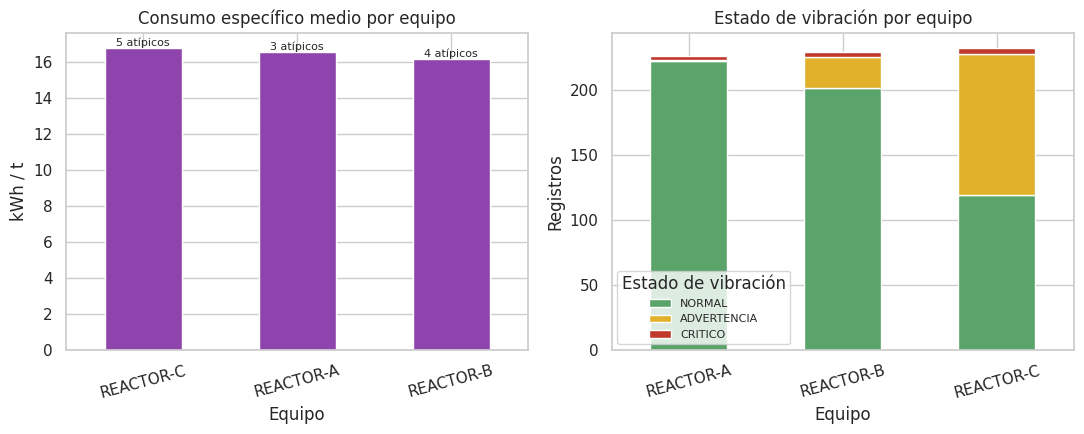

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

orden_equipo = tabla_equipo.sort_values("consumo_especifico_medio", ascending=False).index
tabla_equipo.loc[orden_equipo, "consumo_especifico_medio"].plot(
    kind="bar", ax=axes[0], color="#8E44AD"
)
for pos, equipo in enumerate(orden_equipo):
    axes[0].text(
        pos,
        tabla_equipo.loc[equipo, "consumo_especifico_medio"],
        f"{int(tabla_equipo.loc[equipo, 'atipicos'])} atípicos",
        ha="center", va="bottom", fontsize=8,
    )
axes[0].set_title("Consumo específico medio por equipo")
axes[0].set_xlabel("Equipo")
axes[0].set_ylabel("kWh / t")
axes[0].tick_params(axis="x", rotation=15)

estados_por_equipo = pd.crosstab(df_silver["equipo_id"], df_silver["estado_vibracion"])
estados_por_equipo = estados_por_equipo.reindex(columns=["NORMAL", "ADVERTENCIA", "CRITICO"], fill_value=0)
estados_por_equipo.plot(kind="bar", stacked=True, ax=axes[1], color=["#5AA469", "#E1B12C", "#C0392B"])
axes[1].set_title("Estado de vibración por equipo")
axes[1].set_xlabel("Equipo")
axes[1].set_ylabel("Registros")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Estado de vibración", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación grupal 7

1. ¿Qué equipo presenta el mayor consumo específico medio? ¿Qué evidencia lo demuestra?
2. ¿Qué equipo concentra más atípicos operativos?
3. ¿Podemos afirmar que un equipo es menos eficiente o que tiene una falla? ¿Qué información adicional necesitaríamos?
4. ¿Por qué es importante que Silver no contenga `operador_nombre`?

**Respuesta del grupo:**  
>
1. El REACTOR-C presenta el mayor consumo específico medio, con un valor aproximado de 16,758 kWh/t, superior al de REACTOR-A (16,556 kWh/t) y REACTOR-B (16,169 kWh/t). La evidencia se observa tanto en la tabla resumen como en el gráfico de barras, donde REACTOR-C ocupa la primera posición en consumo específico.
>
2. El REACTOR-C concentra la mayor cantidad de atípicos operativos, con 5 registros atípicos, seguido por REACTOR-B con 4 y REACTOR-A con 3. Esto sugiere una mayor frecuencia de comportamientos fuera de los parámetros esperados para dicho equipo.
>
3. No es posible afirmar de manera concluyente que un equipo sea menos eficiente o presente una falla únicamente con estos indicadores. Para realizar una evaluación técnica sólida sería necesario incorporar información adicional, como históricos de mantenimiento, condiciones de operación, antigüedad de los equipos, carga de trabajo, límites de diseño y tendencias temporales de las variables de proceso. Los resultados actuales permiten identificar señales de alerta, pero no establecer causalidad.
>
4. Es importante que la capa Silver no contenga el campo operador_nombre porque esta capa debe enfocarse en datos limpios, estandarizados y orientados al análisis. Eliminar información personal reduce riesgos de privacidad, cumple principios de minimización de datos y evita sesgos en los análisis, permitiendo que las evaluaciones se centren en el desempeño de los procesos y equipos, y no en personas específicas.


## 8. Evidencia visual

Los gráficos deben responder preguntas. No se evalúa producir muchos gráficos, sino seleccionar evidencia útil e interpretarla sin afirmar causalidad cuando sólo existe asociación.


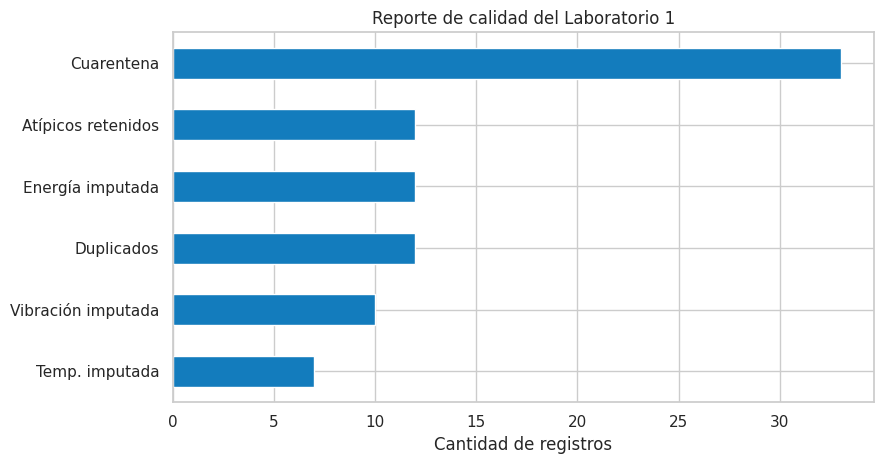

In [ ]:
reporte_calidad = pd.Series({
    "Duplicados": int(duplicados.sum()),
    "Cuarentena": len(df_cuarentena),
    "Temp. imputada": int(df["temperatura_imputada"].sum()),
    "Vibración imputada": int(df["vibracion_imputada"].sum()),
    "Energía imputada": int(df["energia_imputada"].sum()),
    "Atípicos retenidos": int(df_silver["atipico_operativo"].sum()),
})
ax = reporte_calidad.sort_values().plot(kind="barh", figsize=(9, 4.8), color="#137CBD")
ax.set_title("Reporte de calidad del Laboratorio 1")
ax.set_xlabel("Cantidad de registros")
plt.tight_layout()
plt.show()

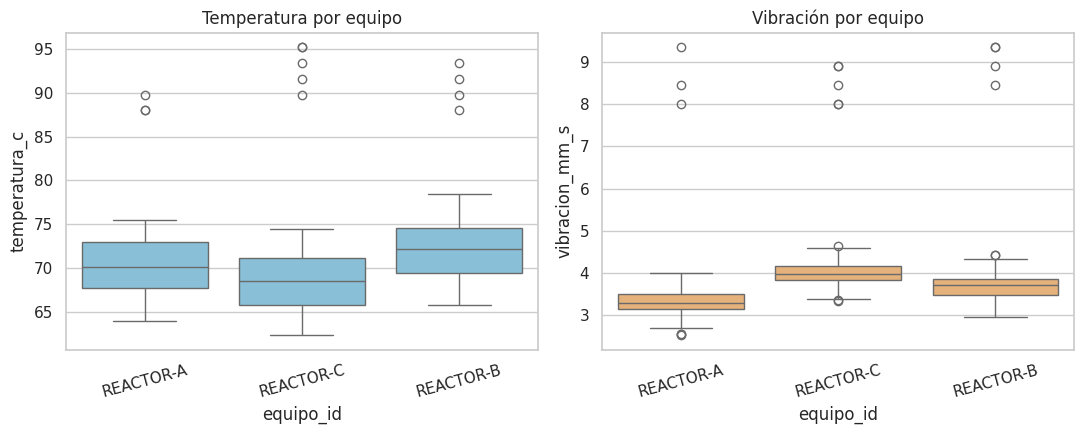

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df_silver, x="equipo_id", y="temperatura_c", ax=axes[0], color="#7CC4E4")
sns.boxplot(data=df_silver, x="equipo_id", y="vibracion_mm_s", ax=axes[1], color="#F6B26B")
axes[0].set_title("Temperatura por equipo")
axes[1].set_title("Vibración por equipo")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### Interpretación grupal 8

Escriban **tres hallazgos respaldados por una tabla o gráfico**. Para cada uno indiquen:

- qué se observa;
- qué evidencia lo respalda;
- qué decisión podría apoyar;
- qué no se puede concluir todavía.

**Hallazgo 1:**  
Diferencias en consumo específico entre equipos

Qué se observa:
El REACTOR-C presenta el mayor consumo específico medio (16,758 kWh/t), seguido del REACTOR-A (16,556 kWh/t) y el REACTOR-B (16,169 kWh/t).

Evidencia que lo respalda:
La tabla de indicadores por equipo y el gráfico “Consumo específico medio por equipo”.

Qué decisión podría apoyar:
Priorizar una revisión del comportamiento energético del REACTOR-C y compararlo con las condiciones en las que trabaja el REACTOR-B, que presenta el menor consumo específico medio.

Qué no se puede concluir todavía:
No se puede afirmar que el REACTOR-C esté defectuoso o sea intrínsecamente menos eficiente, porque podrían existir diferencias de carga, proceso, producto, condiciones operativas u otras variables que el dataset no permite controlar.

**Hallazgo 2:**  
Concentración de atípicos operativos

Qué se observa:
Se conservaron 12 atípicos operativos plausibles, distribuidos de la siguiente manera:

REACTOR-A: 3
REACTOR-B: 4
REACTOR-C: 5

El REACTOR-C presenta la mayor cantidad.

Evidencia que lo respalda:
La tabla resumen por equipo y el gráfico de consumo específico que incorpora la cantidad de atípicos de cada reactor.

Qué decisión podría apoyar:
Revisar primero los periodos específicos en los que aparecen los cinco eventos atípicos del REACTOR-C y contrastarlos con temperatura, vibración, energía y registros de mantenimiento.

Qué no se puede concluir todavía:
Un atípico no significa automáticamente una falla. Los 12 registros cumplen el contrato físico y son considerados valores plausibles. Es necesario estudiar su contexto antes de determinar su causa.

**Hallazgo 3:**  
 La calidad de los datos requiere controles antes del análisis

Qué se observa:
El reporte de calidad muestra:

12 duplicados.<br>
33 registros en cuarentena.<br>
7 temperaturas imputadas.<br>
10 vibraciones imputadas.<br>
12 energías imputadas.<br>
12 atípicos retenidos.<br>

Después de la preparación, de los 720 registros únicos, 687 pudieron incorporarse a Silver y 33 quedaron en cuarentena.

Evidencia que lo respalda:
El gráfico “Reporte de calidad del Laboratorio 1” y las validaciones finales del pipeline.

Qué decisión podría apoyar:
Fortalecer los controles de calidad desde la generación de los datos, especialmente la prevención de duplicados, validación de fechas, estandarización de formatos y validación de rangos físicos.

Qué no se puede concluir todavía:
No podemos determinar únicamente con esta evidencia si los problemas se originan en sensores, operadores, sistemas de información, transmisión de datos u otra etapa del proceso.


## 9. Validación y cierre técnico

Las validaciones comprueban que el flujo cumple el contrato, que Bronze no fue alterado y que no se perdieron registros entre el conjunto de trabajo, Silver y cuarentena.


In [ ]:
assert len(df_raw) == 732, "La ingesta no coincide con el activo entregado."
assert int(duplicados.sum()) == 12, "Conteo de duplicados inesperado."
assert len(df) == 720, "La deduplicación debe conservar 720 registros únicos."
assert len(df_cuarentena) == 33, "La cuarentena esperada contiene 33 registros."
assert len(df_silver) == 687, "Silver debe contener 687 registros."
assert int(df_silver["atipico_operativo"].sum()) == 12, "Los atípicos plausibles deben conservarse."
assert df_silver["timestamp_utc"].notna().all(), "Silver contiene timestamps inválidos."
assert df_silver["produccion_t"].notna().all(), "Silver contiene producción faltante."
assert df_silver["produccion_t"].between(0, 60).all(), "Producción fuera de contrato."
assert df_silver["temperatura_c"].between(0, 120).all(), "Temperatura fuera de contrato."
assert df_silver["vibracion_mm_s"].between(0, 12).all(), "Vibración fuera de contrato."
assert "operador_nombre" not in df_silver.columns, "PII presente en Silver."
assert df_silver["registro_id"].is_unique, "registro_id debe ser único."
assert len(df_silver) + len(df_cuarentena) == len(df), "Se perdieron registros durante el pipeline."
assert df_bronze.equals(df_raw), "Bronze fue modificado."
print("✓ Todas las validaciones fueron superadas.")

✓ Todas las validaciones fueron superadas.


### Limitaciones y recomendaciones
Las recomendaciones deben relacionarse con evidencia observada. No atribuyan una causa que el dataset no permite comprobar.

El grupo debe registrar:

- **Dos limitaciones del dataset:**
  1. Falta de variables de contexto operacional suficientes.
  El dataset permite analizar temperatura, vibración, energía, producción, turno y equipo, pero no proporciona suficiente información sobre carga de trabajo, producto procesado, características de la materia prima, condiciones ambientales, configuración del proceso, calibración de sensores o detalle del mantenimiento.

  Por ello, podemos identificar asociaciones y diferencias entre equipos, pero no demostrar sus causas.
  2. La información requiere un proceso significativo de preparación y control de calidad.
  Se identificaron 12 duplicados, 33 registros que debieron enviarse a cuarentena y diferentes valores faltantes que requirieron imputación. En consecuencia, los resultados finales dependen de reglas de limpieza, validación e imputación que deben mantenerse documentadas y auditables.

- **Dos recomendaciones para el responsable del proceso:**

  1. Profundizar la revisión del REACTOR-C sin asumir previamente una falla.
  Recomendamos analizar temporalmente los registros del REACTOR-C debido a que presenta simultáneamente el mayor consumo específico medio (16,758 kWh/t) y la mayor cantidad de atípicos operativos (5).

La revisión debería integrar información de mantenimiento, carga, producto, setpoints y calibración de sensores antes de atribuir el comportamiento a una causa específica.

  2. Implementar controles de calidad desde el origen de los datos.
  Recomendamos fortalecer la captura y validación para reducir los problemas encontrados. Entre las medidas posibles se encuentran:
>
impedir registros duplicados mediante identificadores únicos;
normalizar unidades y separadores decimales;
validar los rangos físicos al momento de la captura;
exigir timestamps válidos con zona horaria definida;
diferenciar explícitamente datos faltantes de valores iguales a cero;
evitar códigos centinela como -999 cuando sea posible;
registrar causas de datos faltantes;
mantener indicadores de calidad e imputación.
>
Esta recomendación se sustenta en los 12 duplicados, 33 registros en cuarentena y las imputaciones detectadas durante el laboratorio.




## 10. Cierre y entrega

El código puede exportar Silver, cuarentena y el reporte de calidad para documentar el flujo. Estos archivos son salidas auxiliares de la corrida y **no se entregan por separado**.

La única entrega es este notebook ejecutado, con las tablas, gráficos y mensajes visibles, más las respuestas del grupo en Markdown. No se evalúa escribir código desde cero: se evalúa comprender la evidencia y comunicar decisiones.


In [ ]:
ruta_silver = SALIDA_DIR / f"M3_S5_Lab1_Grupo_{NUMERO_GRUPO}_Silver.csv"
ruta_cuarentena = SALIDA_DIR / f"M3_S5_Lab1_Grupo_{NUMERO_GRUPO}_Cuarentena.csv"
ruta_reporte = SALIDA_DIR / f"M3_S5_Lab1_Grupo_{NUMERO_GRUPO}_Reporte_Calidad.csv"

df_silver.to_csv(ruta_silver, index=False, encoding="utf-8-sig")
df_cuarentena.to_csv(ruta_cuarentena, index=False, encoding="utf-8-sig")
reporte_calidad.rename("cantidad").to_csv(ruta_reporte, encoding="utf-8-sig")

assert ruta_silver.is_file() and ruta_cuarentena.is_file() and ruta_reporte.is_file()
print("Archivos generados:")
for ruta in [ruta_silver, ruta_cuarentena, ruta_reporte]:
    print(" -", ruta)

Archivos generados:
 - salidas_lab1/M3_S5_Lab1_Grupo_G6_Silver.csv
 - salidas_lab1/M3_S5_Lab1_Grupo_G6_Cuarentena.csv
 - salidas_lab1/M3_S5_Lab1_Grupo_G6_Reporte_Calidad.csv


## Evidencia de participación de todos los integrantes

Antes de entregar, cada integrante debe indicar qué hallazgo, limitación o recomendación ayudó a construir. Esta evidencia no reemplaza la interpretación grupal: demuestra que todos participaron en ella.

| Integrante | Aporte explicado por la persona | Evidencia revisada |
|---|---|---|
| **QUENALLATA RODRÍGUEZ PAOLA ANDREA** | Participó en la identificación de problemas de calidad del dataset, especialmente los registros duplicados y el riesgo que representan para los indicadores operativos. | Auditoría inicial: identificación de **12 registros duplicados** y análisis de su posible impacto sobre producción, consumo energético e indicadores. |
| **TAKUSI ÁVILA MIDORI MARGOTH** | Participó en el análisis de datos faltantes y en la justificación de los criterios de imputación, diferenciando los datos que pueden estimarse de aquellos que no deben imputarse automáticamente. | Proceso de imputación: **7 valores de temperatura, 10 de vibración y 12 de energía imputados**, manteniendo banderas de trazabilidad. |
| **ZANCA RODRÍGUEZ RICHARD ADRIAN** | Participó en la revisión del contrato físico y la cuarentena, analizando la diferencia entre registros inválidos y valores atípicos operativamente plausibles. | Identificación de **33 registros enviados a cuarentena** por incumplimiento de reglas físicas y conservación de **12 atípicos plausibles** en Silver. |
| **TUCUMÁN ALARCÓN REMBERT RODRIGO** | Participó en la interpretación de los indicadores por equipo y en el análisis comparativo del consumo específico, considerando las limitaciones para establecer causalidad. | Tabla y gráfico de consumo específico: **REACTOR-C = 16,758 kWh/t**, **REACTOR-A = 16,556 kWh/t** y **REACTOR-B = 16,169 kWh/t**. |
| **POKA YUJRA EDDY** | Participó en la elaboración de las limitaciones y recomendaciones finales, relacionando los problemas de calidad encontrados con posibles mejoras en la captura y control de los datos. | Revisión del reporte final de calidad: **12 duplicados, 33 registros en cuarentena, imputaciones realizadas y 12 atípicos retenidos**, además de la recomendación de fortalecer los controles de calidad desde el origen. |

## Checklist grupal

- [X] El grupo ejecutó el notebook de principio a fin.
- [X] Todos los integrantes revisaron tablas y gráficos.
- [X] Bronze permanece intacto.
- [X] Cada imputación tiene bandera y justificación.
- [X] Cuarentena conserva registros y motivos.
- [X] Silver no contiene nombres de operadores.
- [X] Se documentaron tres hallazgos, dos limitaciones y dos recomendaciones.
- [X] La única entrega es el notebook ejecutado; los CSV no se entregan por separado.
